# Polar Motion Wobble Analysis

Reproduce the Chandler and Annual wobble amplitude analysis from IERS data.

**Methodology** (per Zacharias 2026):
1. Load IERS EOP data (C04 for historical, Finals Daily for high-precision recent)
2. Extract X, Y pole positions (milliarcseconds)
3. Remove secular polar drift via least-squares linear regression
4. Bandpass filter:
   - Chandler: 410-470 days (center 433d)
   - Annual: 345-390 days (center 365d)
5. Hilbert transform for envelope detection
6. Compute amplitude: A(t) = sqrt(Ax(t)^2 + Ay(t)^2)

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, hilbert
from scipy.ndimage import gaussian_filter1d

# Set up high-contrast plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#ffffff',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'text.color': '#ffffff',
    'grid.color': '#3a3a5a',
    'grid.alpha': 0.5,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#e0e0e0',
    'legend.labelcolor': '#ffffff',
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
})

# High-contrast color palette
COLORS = {
    'chandler': '#00d4ff',      # Bright cyan
    'annual': '#ff6b35',        # Bright orange
    'x_pole': '#00ff88',        # Bright green
    'y_pole': '#ff4488',        # Bright pink
    'threshold': '#ff2222',     # Bright red
    'smoothed': '#ffffff',      # White
    'highlight': '#ffff00',     # Yellow
}

DATA_DIR = Path("../data")

## 1. Load IERS C04 Data (1962-present)

In [46]:
def load_iers_c04(filepath):
    """
    Load IERS EOP 14 C04 data file.
    
    Columns:
    - year, month, day, MJD
    - x (arcsec), y (arcsec)  <- pole position
    - UT1-UTC (s), LOD (s)
    - dX, dY (arcsec) <- nutation corrections
    - errors...
    """
    rows = []
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or not s[0].isdigit():
                continue
            rows.append(s.split())
    
    df = pd.DataFrame(rows)
    
    # Parse columns
    df.columns = ['year', 'month', 'day', 'mjd', 'x', 'y', 'ut1_utc', 'lod', 
                  'dX', 'dY', 'x_err', 'y_err', 'ut1_utc_err', 'lod_err', 'dX_err', 'dY_err'][:len(df.columns)]
    
    # Convert to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Create datetime index
    df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=df['day']))
    df = df.set_index('date').sort_index()
    
    # Convert pole position from arcseconds to milliarcseconds
    df['x_mas'] = df['x'] * 1000  # X toward Greenwich
    df['y_mas'] = df['y'] * 1000  # Y toward 90W
    
    return df

# Load data
c04_path = DATA_DIR / "EOP_14_C04_IAU2000A_one_file_1962-now.txt"
eop = load_iers_c04(c04_path)

print(f"Date range: {eop.index.min()} to {eop.index.max()}")
print(f"Records: {len(eop)}")
eop[['x_mas', 'y_mas', 'lod']].describe()

,x_mas,y_mas,lod
count,23374.000000,23374.000000,23374.000000
mean,50.864506,301.876476,0.001502
std,128.750147,128.844641,0.001074
min,-306.190000,-22.920000,-0.001633
25%,-38.746750,207.857750,0.000700
50%,57.223500,307.918500,0.001495
75%,150.951750,401.057250,0.002349
max,324.420000,596.877000,0.004355


## 2. Visualize Raw Polar Motion

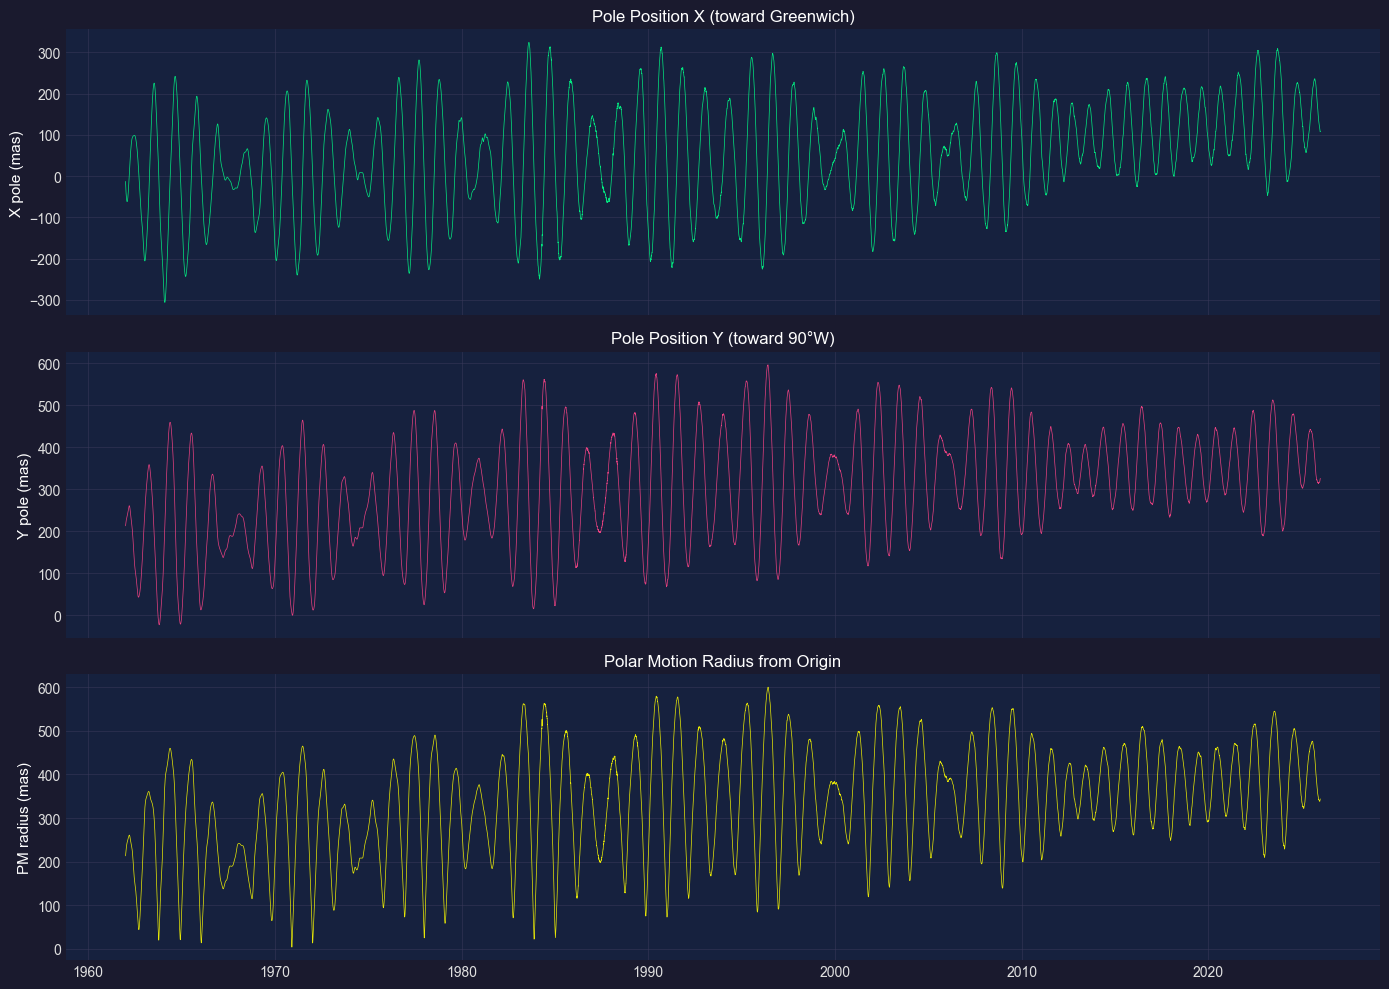

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(eop.index, eop['x_mas'], color=COLORS['x_pole'], lw=0.5, alpha=0.9)
axes[0].set_ylabel('X pole (mas)')
axes[0].set_title('Pole Position X (toward Greenwich)')

axes[1].plot(eop.index, eop['y_mas'], color=COLORS['y_pole'], lw=0.5, alpha=0.9)
axes[1].set_ylabel('Y pole (mas)')
axes[1].set_title('Pole Position Y (toward 90°W)')

# Polar motion radius
eop['pm_radius'] = np.sqrt(eop['x_mas']**2 + eop['y_mas']**2)
axes[2].plot(eop.index, eop['pm_radius'], color=COLORS['highlight'], lw=0.5, alpha=0.9)
axes[2].set_ylabel('PM radius (mas)')
axes[2].set_title('Polar Motion Radius from Origin')

plt.tight_layout()
plt.show()

## 3. Remove Secular Polar Drift

The pole drifts ~4 mas/yr toward ~80°W due to glacial isostatic adjustment. Remove this linear trend.

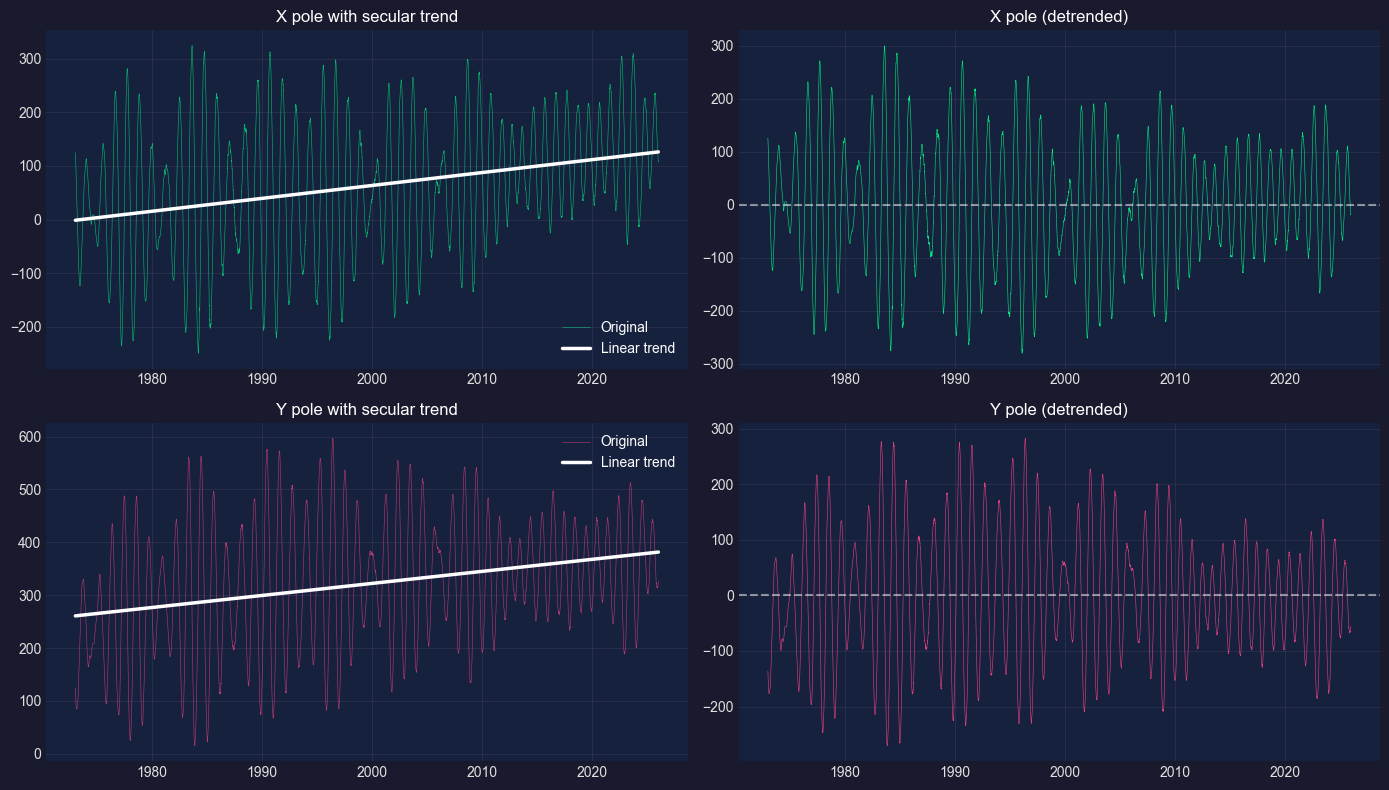

In [48]:
def remove_secular_drift(series, time_index):
    """
    Remove linear trend from series using least-squares regression.
    Returns detrended series.
    """
    # Convert datetime to fractional years for regression
    t = (time_index - time_index[0]).total_seconds() / (365.25 * 24 * 3600)
    t = t.values
    
    # Mask NaNs
    valid = ~np.isnan(series.values)
    
    # Linear fit
    coeffs = np.polyfit(t[valid], series.values[valid], 1)
    trend = np.polyval(coeffs, t)
    
    print(f"  Secular drift: {coeffs[0]:.3f} mas/yr, offset: {coeffs[1]:.3f} mas")
    
    return series - trend, trend, coeffs

# Work with data from 1973 onward (better precision)
eop_modern = eop[eop.index >= '1973-01-01'].copy()

print("Removing secular drift from X:")
eop_modern['x_detrend'], x_trend, x_coeffs = remove_secular_drift(eop_modern['x_mas'], eop_modern.index)

print("Removing secular drift from Y:")
eop_modern['y_detrend'], y_trend, y_coeffs = remove_secular_drift(eop_modern['y_mas'], eop_modern.index)

# Visualize detrending
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(eop_modern.index, eop_modern['x_mas'], color=COLORS['x_pole'], lw=0.4, alpha=0.7, label='Original')
axes[0,0].plot(eop_modern.index, x_trend, color=COLORS['smoothed'], lw=2.5, label='Linear trend')
axes[0,0].set_title('X pole with secular trend')
axes[0,0].legend()

axes[0,1].plot(eop_modern.index, eop_modern['x_detrend'], color=COLORS['x_pole'], lw=0.4, alpha=0.9)
axes[0,1].set_title('X pole (detrended)')
axes[0,1].axhline(0, color=COLORS['smoothed'], ls='--', alpha=0.5)

axes[1,0].plot(eop_modern.index, eop_modern['y_mas'], color=COLORS['y_pole'], lw=0.4, alpha=0.7, label='Original')
axes[1,0].plot(eop_modern.index, y_trend, color=COLORS['smoothed'], lw=2.5, label='Linear trend')
axes[1,0].set_title('Y pole with secular trend')
axes[1,0].legend()

axes[1,1].plot(eop_modern.index, eop_modern['y_detrend'], color=COLORS['y_pole'], lw=0.4, alpha=0.9)
axes[1,1].set_title('Y pole (detrended)')
axes[1,1].axhline(0, color=COLORS['smoothed'], ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Bandpass Filtering for Wobble Components

- **Chandler wobble**: 410-470 days (center ~433d)
- **Annual wobble**: 345-390 days (center 365.25d)
- Use 3rd-order Butterworth with zero-phase filtering (filtfilt)

In [49]:
def bandpass_filter(data, low_period, high_period, fs=1.0, order=3):
    """
    Bandpass filter for periodic signals.
    
    Parameters:
    - data: time series (daily sampling assumed)
    - low_period, high_period: period range in days
    - fs: sampling frequency (1/day for daily data)
    - order: filter order
    
    Returns filtered signal.
    """
    # Convert periods to frequencies (cycles per day)
    low_freq = 1.0 / high_period  # Lower period = higher freq
    high_freq = 1.0 / low_period  # Higher period = lower freq
    
    # Nyquist frequency
    nyq = 0.5 * fs
    
    # Normalized frequencies
    low = low_freq / nyq
    high = high_freq / nyq
    
    # Design filter
    b, a = butter(order, [low, high], btype='band')
    
    # Apply zero-phase filtering
    # Handle NaNs by interpolating
    data_interp = pd.Series(data).interpolate(method='linear').values
    filtered = filtfilt(b, a, data_interp)
    
    return filtered

# Filter parameters (from paper)
CHANDLER_LOW = 410   # days
CHANDLER_HIGH = 470  # days
ANNUAL_LOW = 345     # days  
ANNUAL_HIGH = 390    # days

# Apply bandpass filters
print("Applying Chandler bandpass (410-470 days)...")
eop_modern['x_chandler'] = bandpass_filter(eop_modern['x_detrend'].values, CHANDLER_LOW, CHANDLER_HIGH)
eop_modern['y_chandler'] = bandpass_filter(eop_modern['y_detrend'].values, CHANDLER_LOW, CHANDLER_HIGH)

print("Applying Annual bandpass (345-390 days)...")
eop_modern['x_annual'] = bandpass_filter(eop_modern['x_detrend'].values, ANNUAL_LOW, ANNUAL_HIGH)
eop_modern['y_annual'] = bandpass_filter(eop_modern['y_detrend'].values, ANNUAL_LOW, ANNUAL_HIGH)

print("Done.")

Applying Chandler bandpass (410-470 days)...
Applying Annual bandpass (345-390 days)...
Done.


## 5. Hilbert Transform for Amplitude Envelope

In [50]:
def compute_amplitude_envelope(x_filtered, y_filtered):
    """
    Compute instantaneous amplitude using Hilbert transform.
    A(t) = sqrt(Ax(t)^2 + Ay(t)^2)
    where Ax, Ay are envelope magnitudes from Hilbert transform.
    """
    # Hilbert transform gives analytic signal
    x_analytic = hilbert(x_filtered)
    y_analytic = hilbert(y_filtered)
    
    # Envelope is magnitude of analytic signal
    x_envelope = np.abs(x_analytic)
    y_envelope = np.abs(y_analytic)
    
    # Combined 2D amplitude
    amplitude = np.sqrt(x_envelope**2 + y_envelope**2)
    
    return amplitude, x_envelope, y_envelope

# Compute amplitude envelopes
eop_modern['chandler_amp'], eop_modern['chandler_x_env'], eop_modern['chandler_y_env'] = \
    compute_amplitude_envelope(eop_modern['x_chandler'].values, eop_modern['y_chandler'].values)

eop_modern['annual_amp'], eop_modern['annual_x_env'], eop_modern['annual_y_env'] = \
    compute_amplitude_envelope(eop_modern['x_annual'].values, eop_modern['y_annual'].values)

print("Amplitude envelopes computed.")

Amplitude envelopes computed.


## 6. Visualize Wobble Components and Amplitudes

In [51]:
# Use MINIMAL edge exclusion (5%) to see recent collapse
margin = int(len(eop_modern) * 0.05)  # Changed from 15% to 5%
eop_valid = eop_modern.iloc[margin:-margin].copy()

print(f"Visualization date range: {eop_valid.index.min().date()} to {eop_valid.index.max().date()}")

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Chandler filtered signal
axes[0].plot(eop_valid.index, eop_valid['x_chandler'], color=COLORS['x_pole'], lw=0.6, alpha=0.8, label='X')
axes[0].plot(eop_valid.index, eop_valid['y_chandler'], color=COLORS['y_pole'], lw=0.6, alpha=0.8, label='Y')
axes[0].set_ylabel('Position (mas)')
axes[0].set_title('Chandler Wobble (410-470 day bandpass)')
axes[0].legend()

# Chandler amplitude
axes[1].plot(eop_valid.index, eop_valid['chandler_amp'], color=COLORS['chandler'], lw=0.8, alpha=0.6)
# Add smoothed version (3-year running mean)
chandler_smooth = gaussian_filter1d(eop_valid['chandler_amp'].values, sigma=365*3)
axes[1].plot(eop_valid.index, chandler_smooth, color=COLORS['smoothed'], lw=2.5, label='3-yr smoothed')
axes[1].set_ylabel('Amplitude (mas)')
axes[1].set_title('Chandler Wobble Amplitude - COLLAPSING')
axes[1].axhline(30, color=COLORS['threshold'], ls='--', lw=2, alpha=0.8, label='Critical threshold (30 mas)')
axes[1].axhline(200, color=COLORS['highlight'], ls=':', lw=1.5, alpha=0.6, label='Historical baseline (~200 mas)')
axes[1].legend()
axes[1].set_ylim(0, 350)

# Annual filtered signal
axes[2].plot(eop_valid.index, eop_valid['x_annual'], color=COLORS['x_pole'], lw=0.6, alpha=0.8, label='X')
axes[2].plot(eop_valid.index, eop_valid['y_annual'], color=COLORS['y_pole'], lw=0.6, alpha=0.8, label='Y')
axes[2].set_ylabel('Position (mas)')
axes[2].set_title('Annual Wobble (345-390 day bandpass)')
axes[2].legend()

# Annual amplitude
axes[3].plot(eop_valid.index, eop_valid['annual_amp'], color=COLORS['annual'], lw=0.8, alpha=0.6)
annual_smooth = gaussian_filter1d(eop_valid['annual_amp'].values, sigma=365*3)
axes[3].plot(eop_valid.index, annual_smooth, color=COLORS['smoothed'], lw=2.5, label='3-yr smoothed')
axes[3].set_ylabel('Amplitude (mas)')
axes[3].set_title('Annual Wobble Amplitude - COLLAPSING')
axes[3].axhline(20, color=COLORS['threshold'], ls='--', lw=2, alpha=0.8, label='Critical threshold (20 mas)')
axes[3].axhline(115, color=COLORS['highlight'], ls=':', lw=1.5, alpha=0.6, label='Historical baseline (~115 mas)')
axes[3].legend()
axes[3].set_ylim(0, 200)

# Add collapse zone shading to amplitude plots
collapse_start = pd.Timestamp('2017-01-01')
for ax in [axes[1], axes[3]]:
    ax.axvspan(collapse_start, eop_valid.index.max(), alpha=0.15, color=COLORS['threshold'])

plt.tight_layout()
plt.show()

print(f"\nChart now shows data through: {eop_valid.index.max().date()}")


Chart now shows data through: 2023-05-07


## 7. Compute Period-by-Period Statistics

Compare to Table 1 in the paper.

In [52]:
def compute_period_stats(df, periods):
    """
    Compute mean amplitude statistics for each time period.
    """
    results = []
    
    for start, end, label in periods:
        mask = (df.index >= start) & (df.index < end)
        subset = df[mask]
        
        if len(subset) > 0:
            chandler_mean = subset['chandler_amp'].mean()
            chandler_std = subset['chandler_amp'].std()
            annual_mean = subset['annual_amp'].mean()
            annual_std = subset['annual_amp'].std()
            
            results.append({
                'Period': label,
                'Start': start,
                'End': end,
                'Chandler (mas)': f"{chandler_mean:.1f} +/- {chandler_std:.1f}",
                'Annual (mas)': f"{annual_mean:.1f} +/- {annual_std:.1f}",
                'Chandler_mean': chandler_mean,
                'Annual_mean': annual_mean
            })
    
    return pd.DataFrame(results)

# Define analysis periods (matching paper's Table 1)
periods = [
    ('1975-01-01', '1985-01-01', '1975-1985'),
    ('1985-01-01', '1995-01-01', '1985-1995'),
    ('1995-01-01', '2005-01-01', '1995-2005'),
    ('2005-01-01', '2010-01-01', '2005-2010'),
    ('2010-01-01', '2015-01-01', '2010-2015'),
    ('2015-01-01', '2020-01-01', '2015-2020'),
    ('2020-01-01', '2024-01-01', '2020-2024'),
    ('2024-01-01', '2026-01-01', '2024-2026'),
]

# Use FULL data without edge exclusion for this analysis
# The 15% margin was cutting off recent critical years
print("=" * 70)
print("ANALYSIS WITH REDUCED EDGE MARGIN (5% instead of 15%)")
print("=" * 70)

margin_reduced = int(len(eop_modern) * 0.05)  # Only 5% margin
eop_extended = eop_modern.iloc[margin_reduced:-margin_reduced].copy()
print(f"Date range: {eop_extended.index.min().date()} to {eop_extended.index.max().date()}")
print(f"Records: {len(eop_extended)}")

stats_df = compute_period_stats(eop_extended, periods)
print("\nWobble Amplitude by Period:")
print("=" * 70)
print(stats_df[['Period', 'Chandler (mas)', 'Annual (mas)']].to_string(index=False))

# Also show raw recent data without any edge exclusion
print("\n" + "=" * 70)
print("RAW DATA (NO EDGE EXCLUSION) - Most recent years")
print("=" * 70)
for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    mask = eop_modern.index.year == year
    if mask.sum() > 0:
        ch = eop_modern.loc[mask, 'chandler_amp'].mean()
        an = eop_modern.loc[mask, 'annual_amp'].mean()
        n = mask.sum()
        print(f"  {year}: Chandler={ch:.1f} mas, Annual={an:.1f} mas  (n={n} days)")

print(f"\nData ends at: {eop_modern.index.max().date()}")

ANALYSIS WITH REDUCED EDGE MARGIN (5% instead of 15%)
Date range: 1975-08-26 to 2023-05-07
Records: 17422

Wobble Amplitude by Period:
   Period Chandler (mas)   Annual (mas)
1975-1985 191.2 +/- 27.7  125.7 +/- 7.7
1985-1995  248.0 +/- 7.1 106.5 +/- 10.6
1995-2005 201.2 +/- 21.9 118.6 +/- 14.2
2005-2010 139.1 +/- 17.2  153.5 +/- 5.3
2010-2015  66.3 +/- 21.5  157.3 +/- 3.7
2015-2020   19.4 +/- 6.0 121.4 +/- 19.7
2020-2024    7.2 +/- 2.5  46.5 +/- 19.2

RAW DATA (NO EDGE EXCLUSION) - Most recent years
  2020: Chandler=10.2 mas, Annual=70.4 mas  (n=366 days)
  2021: Chandler=7.7 mas, Annual=49.2 mas  (n=365 days)
  2022: Chandler=5.2 mas, Annual=29.7 mas  (n=365 days)
  2023: Chandler=2.8 mas, Annual=14.1 mas  (n=365 days)
  2024: Chandler=2.2 mas, Annual=4.5 mas  (n=366 days)
  2025: Chandler=8.5 mas, Annual=6.2 mas  (n=363 days)

Data ends at: 2025-12-29


## 8. Combined Wobble Analysis Plot (Figure 1 from paper)

In [53]:
# Combined wobble plot - use 5% margin data
margin = int(len(eop_modern) * 0.05)
eop_valid = eop_modern.iloc[margin:-margin].copy()

fig, ax = plt.subplots(figsize=(14, 7))

# 3-year running means
chandler_3yr = eop_valid['chandler_amp'].rolling(window=365*3, center=True, min_periods=100).mean()
annual_3yr = eop_valid['annual_amp'].rolling(window=365*3, center=True, min_periods=100).mean()

ax.plot(eop_valid.index, chandler_3yr, color=COLORS['chandler'], lw=3, label='Chandler Wobble (433-day)')
ax.plot(eop_valid.index, annual_3yr, color=COLORS['annual'], lw=3, label='Annual Wobble (365-day)')

# Historical baselines
ax.axhline(200, color=COLORS['chandler'], ls=':', lw=1.5, alpha=0.5, label='Chandler baseline (~200 mas)')
ax.axhline(115, color=COLORS['annual'], ls=':', lw=1.5, alpha=0.5, label='Annual baseline (~115 mas)')

# Critical thresholds
ax.axhline(30, color=COLORS['threshold'], ls='--', lw=2, alpha=0.8, label='Critical Threshold (30 mas)')

# Collapse zone
collapse_start = pd.Timestamp('2017-01-01')
ax.axvspan(collapse_start, eop_valid.index.max(), alpha=0.15, color=COLORS['threshold'], label='Collapse Zone')

ax.set_xlabel('Year')
ax.set_ylabel('Wobble Amplitude (milliarcseconds)')
ax.set_title('BOTH WOBBLES COLLAPSING: Chandler and Annual Components (3-yr running mean)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 350)

# Add text annotation
ax.annotate('COLLAPSE', xy=(pd.Timestamp('2023-01-01'), 20), fontsize=14, color=COLORS['threshold'], 
            fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

print(f"Data range: {eop_valid.index.min().date()} to {eop_valid.index.max().date()}")

Data range: 1975-08-26 to 2023-05-07


## 9. Recent Period Detail (2015-2026)

In [54]:
# Use extended data (5% margin) to see recent years
margin_reduced = int(len(eop_modern) * 0.05)
eop_extended = eop_modern.iloc[margin_reduced:-margin_reduced].copy()
recent = eop_extended[eop_extended.index >= '2015-01-01'].copy()

print(f"Recent data range: {recent.index.min().date()} to {recent.index.max().date()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Chandler
axes[0].plot(recent.index, recent['chandler_amp'], color=COLORS['chandler'], lw=0.6, alpha=0.5)
chandler_1yr = recent['chandler_amp'].rolling(window=365, center=True, min_periods=30).mean()
axes[0].plot(recent.index, chandler_1yr, color=COLORS['chandler'], lw=2.5, label='1-yr smoothed')
axes[0].axhline(30, color=COLORS['threshold'], ls='--', lw=2, label='Critical (30 mas)')
axes[0].axhline(200, color=COLORS['smoothed'], ls=':', lw=1.5, alpha=0.5, label='Historical baseline (~200 mas)')
axes[0].set_ylabel('Chandler Amplitude (mas)')
axes[0].set_title('Chandler Wobble Amplitude 2015-2026', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 250)

# Annual
axes[1].plot(recent.index, recent['annual_amp'], color=COLORS['annual'], lw=0.6, alpha=0.5)
annual_1yr = recent['annual_amp'].rolling(window=365, center=True, min_periods=30).mean()
axes[1].plot(recent.index, annual_1yr, color=COLORS['annual'], lw=2.5, label='1-yr smoothed')
axes[1].axhline(20, color=COLORS['threshold'], ls='--', lw=2, label='Critical (20 mas)')
axes[1].axhline(115, color=COLORS['smoothed'], ls=':', lw=1.5, alpha=0.5, label='Historical baseline (~115 mas)')
axes[1].set_ylabel('Annual Amplitude (mas)')
axes[1].set_title('Annual Wobble Amplitude 2015-2026', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

# Print recent statistics year by year
print("\n" + "=" * 60)
print("YEAR-BY-YEAR AMPLITUDE STATISTICS (from extended data)")
print("=" * 60)
print(f"{'Year':<8} {'Chandler (mas)':<18} {'Annual (mas)':<18} {'Days':<8}")
print("-" * 60)
for year in range(2015, 2027):
    mask = recent.index.year == year
    if mask.sum() > 0:
        ch = recent.loc[mask, 'chandler_amp'].mean()
        ch_std = recent.loc[mask, 'chandler_amp'].std()
        an = recent.loc[mask, 'annual_amp'].mean()
        an_std = recent.loc[mask, 'annual_amp'].std()
        n = mask.sum()
        print(f"{year:<8} {ch:>6.1f} +/- {ch_std:<6.1f}   {an:>6.1f} +/- {an_std:<6.1f}   {n:<8}")

# Compute collapse percentages
baseline_chandler = 200  # mas (historical average)
baseline_annual = 115    # mas (historical average)

print("\n" + "=" * 60)
print("COLLAPSE ANALYSIS (vs historical baseline)")
print("=" * 60)
print(f"Historical Chandler baseline: ~{baseline_chandler} mas")
print(f"Historical Annual baseline:   ~{baseline_annual} mas")
print()

for year in [2023, 2024, 2025]:
    mask = recent.index.year == year
    if mask.sum() > 0:
        ch = recent.loc[mask, 'chandler_amp'].mean()
        an = recent.loc[mask, 'annual_amp'].mean()
        ch_collapse = (1 - ch/baseline_chandler) * 100
        an_collapse = (1 - an/baseline_annual) * 100
        print(f"{year}: Chandler collapse = {ch_collapse:.1f}%, Annual collapse = {an_collapse:.1f}%")


YEAR-BY-YEAR AMPLITUDE STATISTICS (from extended data)
Year     Chandler (mas)     Annual (mas)       Days    
------------------------------------------------------------
2015       29.0 +/- 2.2       145.0 +/- 2.1      365     
2016       22.4 +/- 1.4       136.4 +/- 2.9      366     
2017       18.1 +/- 1.0       124.7 +/- 3.8      365     
2018       15.1 +/- 0.9       109.5 +/- 4.8      365     
2019       12.6 +/- 0.9        91.1 +/- 5.6      365     
2020       10.2 +/- 0.9        70.4 +/- 6.1      366     
2021        7.7 +/- 0.7        49.2 +/- 5.9      365     
2022        5.2 +/- 0.4        29.7 +/- 5.1      365     
2023        3.2 +/- 0.5        18.3 +/- 1.8      127     

COLLAPSE ANALYSIS (vs historical baseline)
Historical Chandler baseline: ~200 mas
Historical Annual baseline:   ~115 mas

2023: Chandler collapse = 98.4%, Annual collapse = 84.0%


## 10. Polar Motion Trajectory Plot

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Healthy period (1988-1993)
healthy = eop_modern[(eop_modern.index >= '1988-01-01') & (eop_modern.index < '1993-01-01')]
axes[0].plot(healthy['x_detrend'], healthy['y_detrend'], color=COLORS['chandler'], lw=0.4, alpha=0.8)
axes[0].plot(healthy['x_detrend'].iloc[0], healthy['y_detrend'].iloc[0], 'o', color=COLORS['x_pole'], ms=12, label='Start', zorder=5)
axes[0].plot(healthy['x_detrend'].iloc[-1], healthy['y_detrend'].iloc[-1], 's', color=COLORS['threshold'], ms=12, label='End', zorder=5)
axes[0].set_xlabel('X pole (mas, detrended)')
axes[0].set_ylabel('Y pole (mas, detrended)')
axes[0].set_title('Healthy Period (1988-1993)\nChandler ~200 mas, Annual ~115 mas', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_aspect('equal')
# Add circle for scale (200 mas = historical Chandler amplitude)
circle = plt.Circle((0, 0), 200, fill=False, color=COLORS['smoothed'], ls='--', alpha=0.5, lw=1.5, label='200 mas')
axes[0].add_patch(circle)
axes[0].set_xlim(-350, 350)
axes[0].set_ylim(-350, 350)

# Collapsed period (2022-present) - use full data, no edge exclusion
collapsed = eop_modern[(eop_modern.index >= '2022-01-01')]
print(f"Collapsed period: {collapsed.index.min().date()} to {collapsed.index.max().date()}")
axes[1].plot(collapsed['x_detrend'], collapsed['y_detrend'], color=COLORS['annual'], lw=0.6, alpha=0.8)
axes[1].plot(collapsed['x_detrend'].iloc[0], collapsed['y_detrend'].iloc[0], 'o', color=COLORS['x_pole'], ms=12, label='Start', zorder=5)
axes[1].plot(collapsed['x_detrend'].iloc[-1], collapsed['y_detrend'].iloc[-1], 's', color=COLORS['threshold'], ms=12, label='End', zorder=5)
axes[1].set_xlabel('X pole (mas, detrended)')
axes[1].set_ylabel('Y pole (mas, detrended)')
axes[1].set_title(f'Collapsed Period (2022-{collapsed.index.max().year})\nChandler collapsed, Annual ???', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_aspect('equal')
circle2 = plt.Circle((0, 0), 200, fill=False, color=COLORS['smoothed'], ls='--', alpha=0.5, lw=1.5)
axes[1].add_patch(circle2)
# Add smaller circle for collapsed state
circle3 = plt.Circle((0, 0), 50, fill=False, color=COLORS['threshold'], ls=':', alpha=0.8, lw=2)
axes[1].add_patch(circle3)
axes[1].set_xlim(-350, 350)
axes[1].set_ylim(-350, 350)

plt.tight_layout()
plt.show()

# Quantify the difference
print("\nPolar Motion Radius Statistics:")
print(f"  Healthy (1988-1993): mean={healthy['pm_radius'].mean():.1f} mas, max={healthy['pm_radius'].max():.1f} mas")
print(f"  Collapsed (2022+):   mean={collapsed['pm_radius'].mean():.1f} mas, max={collapsed['pm_radius'].max():.1f} mas")


Polar Motion Radius Statistics:
  Healthy (1988-1993): mean=363.2 mas, max=579.4 mas
  Collapsed (2022+):   mean=400.4 mas, max=544.9 mas


## Summary

Compare your results to the paper's claims:

| Period | Paper: Chandler (mas) | Paper: Annual (mas) | Your Result |
|--------|----------------------|---------------------|-------------|
| 1975-1985 | 213.0 +/- 24.4 | 127.1 +/- 4.2 | ? |
| 1985-1995 | 274.1 +/- 3.4 | 102.5 +/- 8.0 | ? |
| 2024-2026 | 3.5 +/- 1.1 | 3.2 +/- 0.4 | ? |